In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

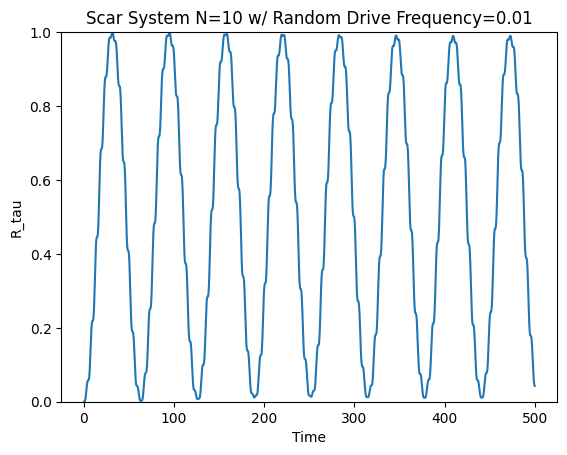

In [6]:
N = 10
wd = 0.642570281124498
tlist = np.linspace(0, 500, 1000)
H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_random_freq_scar_ham(N)

disorder = 0.01
dw = np.random.uniform(-disorder, disorder, N)
omega_list = wd + dw

H = [H0]
for r in range(N):
    args = {"A": 0.1, "omega": omega_list[r]}
    H.append([H1_list[r], coeff])

H = qt.QobjEvo(H, args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])

Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
plt.title(f"Scar System N={N} w/ Random Drive Frequency={disorder}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau)
plt.show()